# Detekcja krawędzi

## Cel ćwiczenia

- Zapoznanie z metodami detekcji krawędzi:
    - Sobel, Prewitt, Roberts - przypomnienie,
    - Laplasjan z Gaussa (LoG – ang. Laplacian of Gaussian),
    - Canny.

Detekcja krawędzi przez wiele lat była podstawą algorytmów segmentacji.
Krawędzie wykrywane są najczęściej z wykorzystaniem pierwszej (gradient) i drugiej (Laplasjan) pochodnej przestrzennej.
Wykorzystanie obu metod zaprezentowane zostało w ćwiczeniu *Przetwarzanie wstępne. Filtracja kontekstowa*.

W niniejszym ćwiczeniu poznane detektory krawędzi zostaną porównane z bardziej zaawansowanymi: Laplasjan z funkcji Gaussa (LoG), Zero Crossing i Canny.

## Laplasjan z Gaussa (LoG)

Funkcja Gaussa:<br>
\begin{equation}
h(r) = e^{\frac{-r^2}{2 \sigma^2}}
\end{equation}<br>
gdzie:
- $r^2 = x^2 + y^2$
- $\sigma$ to odchylenie standardowe.

Działanie filtracji Gaussowskiej zostało przedstawione w ćwiczeniu "Przetwarzanie wstępne". W jej wyniku następuje rozmazanie obrazu.
Laplasjan tej funkcji dany jest wzorem:

\begin{equation}
\nabla^2 h(r) = \frac{r^2 - 2\sigma^2}{\sigma^4} e^{-\frac{r^2}{2\sigma^2}}
\end{equation}

Funkcję (z oczywistych powodów) nazywamy Laplasjan z Gaussa (LoG).
Ponieważ druga pochodna jest operacją liniową, konwolucja obrazu z $\nabla^2 h(r)$ daje taki sam efekt jak zastosowanie filtracji Gaussa na obrazie, a następnie obliczenie Laplasjanu z wyniku.
Lokalizacja krawędzi polega na znalezieniu miejsca, gdzie po filtracji LoG następuje zmiana znaku.

1. Wczytaj obraz *house.png*.
2. Wykonaj rozmycie Gaussowskie obrazu wejściowego.
W tym celu wykorzysaj funkcję `cv2.GaussianBlur(img, kSize, sigma)`.
Pierwszy argument jest obrazem wejśćiowym.
Drugi jest rozmiarem filtru (podanym w nawiasach okrągłych, np. *(3, 3)*).
Trzecim argumentem jest odchylenie standardowe. Wartość jest dobrana automatycznie, jeśli zosanie podana wartość `0` (będą równe rozmiarowi).
3. Oblicz laplasjan obrazu rozmytego.
W tym celu wykorzysaj funkcję `cv2.Laplacian(img, ddepth)`.
Pierszym argumentem jest obraz wejściowy.
Drugim argumentem jest typ danych wejściowych. Użyj `cv2.CV_32F`.
4. Wyznacz miejsca zmiany znaku.
Zaimplementuj funkcję `crossing(LoG, thr)`:
    - Najpierw stwórz tablicę, do której zostanie zapisany wynik.
    Jej rozmiar jest taki sam jak przetwarzanego obrazu.
    - Następnie wykonaj pętle po obrazie (bez ramki jednopikselowej).
    W każdej iteracji stwórz otoczenie o rozmiarze $3 \times 3$.
    Dla otoczenia oblicz wartość maksymalną i minimalną.
    - Jeśli wartości te mają przeciwne znaki, to do danego miejsca tablicy przypisz wartość:
        - jeśli piksel wejściowy > 0, to dodaj do niego wartość bezwzględną minimum.
        - jeśli piksel wejściowy < 0, to do jego wartości bezwzględnej dodaj maksimum.
    - Zmień zakres wykonanej tablicy do $<0, 255>$.
    - Wykonaj progowanie tablicy. Próg jest argumentem wejściowym.
    - Przeskaluj dane binarne do wartości `[0, 255]`.
    - Wykonaj konwersję do typu *uint8*.
    - Wykonaj rozmycie medianowe wyniku.
    Wykorzystaj funkcję `cv2.medianBlur(img, kSize)`.
    Pierwszym argumentem jest obraz wejśćiowy, a drugim rozmiar filtra.
    - Zwróć wyznaczoną tablicę.
5. Wyświetl obraz wynikowy.
6. Dobierz parametry (rozmiar filtru Gaussa, odchylenie standardowe, próg binaryzacji) tak, by widoczne były kontury domu, ale nie dachówki.

In [ ]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import math
import os
import requests

url = 'https://raw.githubusercontent.com/vision-agh/poc_sw/master/09_Canny/'

fileNames = ["dom.png"]
for fileName in fileNames:
  if not os.path.exists(fileName):
      r = requests.get(url + fileName, allow_redirects=True)
      open(fileName, 'wb').write(r.content)



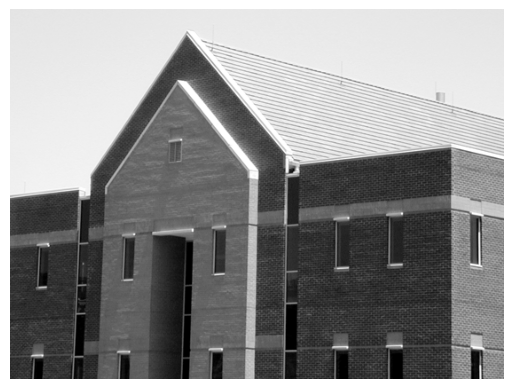

In [ ]:
img = cv2.imread('dom.png', cv2.IMREAD_GRAYSCALE)
plt.axis(False)
plt.imshow(img, 'gray')


In [ ]:
def crossing(LoG, thr):
    rows, cols = LoG.shape
    edges = np.zeros_like(LoG, dtype=np.float32)

    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            neighborhood = LoG[i-1:i+2, j-1:j+2]
            max_val = neighborhood.max()
            min_val = neighborhood.min()
            center = LoG[i, j]
            if min_val < 0 and max_val > 0:
                if center > 0:
                    edges[i, j] = center + abs(min_val)
                else:
                    edges[i, j] = abs(center) + max_val

    # przekonwertowanie do 0 - 255
    edges -= edges.min()
    if edges.max() > 0:
        edges /= edges.max()
    edges *= 255

    # treshold
    _, binary = cv2.threshold(edges, thr, 255, cv2.THRESH_BINARY)
    binary = binary.astype(np.uint8)

    # median blur
    return cv2.medianBlur(binary, 5)

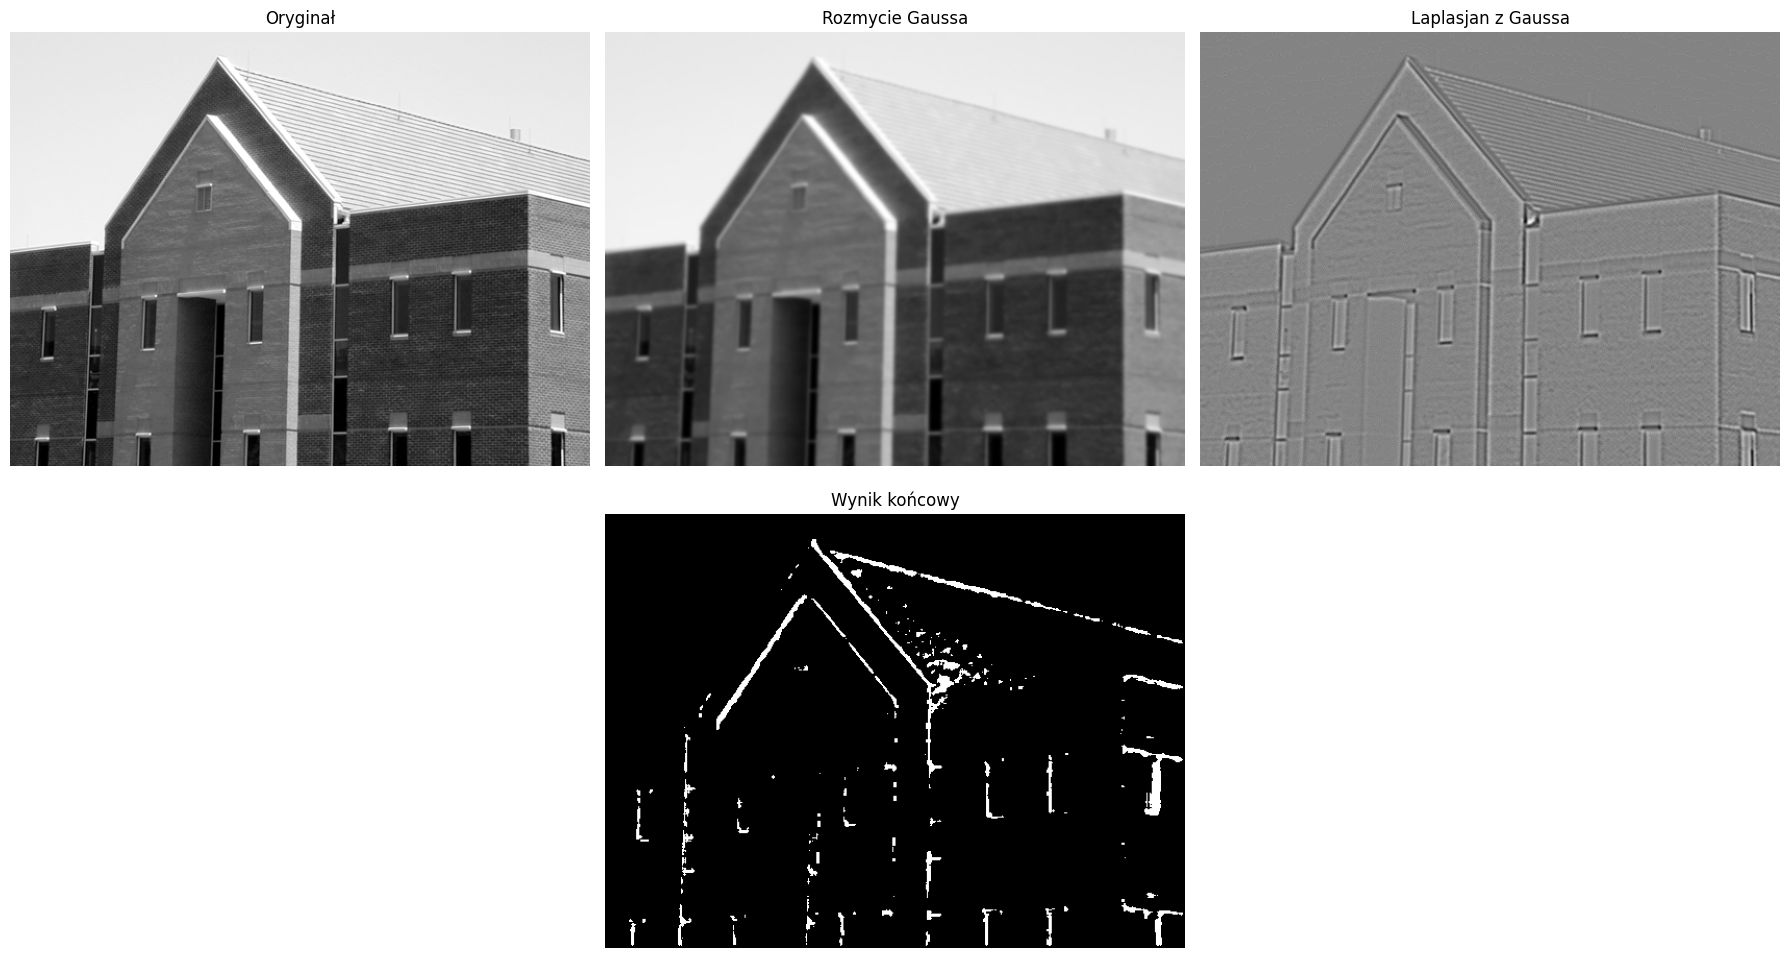

In [ ]:
# ARGUMENTY
GUASS_KSIZE = (13, 13)
SIGMA = 1.5
THRESHOLD = 60


blurred = cv2.GaussianBlur(img, GUASS_KSIZE, SIGMA)

laplacian = cv2.Laplacian(blurred, cv2.CV_32F)

zero_corssing = crossing(laplacian, THRESHOLD)
plt.figure(figsize=(18,10))

plt.subplot(2, 3, 1)
plt.title("Oryginał")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title(f"Rozmycie Gaussa")
plt.imshow(blurred, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title("Laplasjan z Gaussa")
plt.imshow(laplacian, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("Wynik końcowy")
plt.imshow(zero_corssing, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

## Algorytm Canny'ego

> Algorytm Canny'ego to często wykorzystywana metoda detekcji krawędzi.
> Zaproponowana została w 1986r. przez Johna F. Cannego.
> Przy jego projektowaniu założono trzy cele:
> - niska liczba błędów - algorytm powinien znajdywać wszystkie krawędzie oraz generować jak najmniej fałszywych detekcji,
> - punkty krawędziowe powinny być poprawnie lokalizowane - wykryte punkty powinny być jak najbardziej zbliżone do rzeczywistych,
> - krawędzie o szerokości 1 piksela - algorytm powinien zwrócić jeden punkt dla każdej rzeczywistej krawędzi.

Zaimplementuj algorytm detekcji krawędziCanny'ego:
1. W pierwszym kroku obraz przefiltruj dwuwymiarowym filtrem Gaussa.
2. Następnie oblicz gradient pionowy i poziomy ($g_x $ i $g_y$).
Jedną z metod jest filtracja Sobela.
3. Dalej oblicz amplitudę:
$M(x,y)  = \sqrt{g_x^2+g_y^2}$ oraz kąt:
$\alpha(x,y) = arctan(\frac{g_y}{g_x})$.
Do obliczenia kąta wykorzystaj funkcję `np.arctan2(x1, x2)`.
Wynik jest w radianach.
4. W kolejnym etapie wykonaj kwantyzację kątów gradientu.
Kąty od $-180^\circ$ do $180^\circ$ można podzielić na 8 przedziałów:
[$-22.5^\circ, 22.5^\circ$], [$22.5^\circ, 67.5^\circ$],
[$67.5^\circ, 112.5^\circ$], [$112.5^\circ, 157.5^\circ$],
[$157.5^\circ, -157.5^\circ$], [$-157.5^\circ, -112.5^\circ$],
[$-112.5^\circ, -67.5^\circ$], [$-67.5^\circ, -22.5^\circ$].
Przy czym należy rozpatrywać tylko 4 kierunki:
    - pionowy ($d_1$),
    - poziomy ($d_2$),
    - skośny lewy ($d_3$),
    - skośny prawy ($d_4$).
5. Dalej przeprowadź eliminację pikseli, które nie mają wartości maksymalnej (ang. *nonmaximal suppresion*).
Celem tej operacji jest redukcja szerokości krawędzi do rozmiaru 1 piksela.
Algorytm przebiega następująco.
W rozpatrywanym otoczeniu o rozmiarze $3 \times 3$:
    - określ do którego przedziału należy kierunek gradientu piksela centralnego ($d_1, d_2, d_3, d_4$).
    - przeanalizuje sąsiadów leżących na tym kierunku.
Jeśli choć jeden z nich ma amplitudę większą niż piksel centralny, to należy uznać, że nie jest lokalnym maksimum i do wyniku przypisać $g_N(x,y) = 0$.
W przeciwnym przypadku $g_N(x,y) = M(x,y)$.
Przez $g_N$ rozumiemy obraz detekcji lokalnych maksimów.
Zaimplementuj funkcję `nonmax`.
Pierwszym argementem jest macierz kierunków (po kwantyzacji).
Drugim argumentem jest macierz amplitudy.
6. Ostatnią operacją jest binaryzacja obrazu $g_N$.
Stosuje się tutaj tzw. binaryzację z histerezą.
Wykorzystuje się w niej dwa progi: $T_L$ i $T_H$, przy czym $T_L < T_H$.
Canny zaproponował, aby stosunek progu wyższego do niższego był jak 3 lub 2 do 1.
Rezultaty binaryzacji można opisać jako:<br>
$g_{NH}(x,y) = g_N(x,y) \geq TH $<br>
$g_{NL}(x,y) = TH > g_N(x,y) \geq TL $<br>
Można powiedzieć, że na obrazie $g_{NH}$ są "pewne" krawędzie.
Natomiast na $g_{NL}$ "potencjalne".
Często krawędzie "pewne" nie są ciągłe.
Dlatego wykorzystuje się obraz $g_{NL}$ w następującej procedurze:
    - Stwórz stos zawierający wszystkie piksele zaznaczone na obrazie $g_{NH}$.
W tym celu wykorzystaj listę współrzędnych `[row, col]`.
Do pobrania elementu z początku służy metoda `list.pop()`.
Do dodania elementu na koniec listy służy metoda `list.append(new)`.
    - Stwórz obraz, który będzie zawierał informację czy dany piksel został już odwiedzony.
    - Stwórz obraz, któy zawierać będzie wynikowe krawędzie.
Jej rozmiar jest równy rozmiarowi obrazu.
    - Wykonaj pętlę, która będzie pobierać elementy z listy, dopóki ta nie będzie pusta.
W tym celu najlepiej sprawdzi się pętla `while`.
    - W każdej iteracji pobierz element ze stosu.
    - Sprawdź czy dany element został już odwiedzony.
    - Jeśli nie został, to:
        - Oznacz go jako odwiedzony,
        - Oznacz piksel jako krawędź w wyniku,
        - Sprawdź otoczenie piksela w obrazie $g_{NL}$,
        - Dodaj do stosu współrzędne otoczenia, które zawierają krawędź (potencjalną).
        Można to wykoanać np. pętlą po stworzonym otoczeniu.
7. Wyświetl obraz oryginalny, obraz $g_{NH}$ oraz obraz wynikowy.

Pomocnicze obrazy $g_{NH}$ i $g_{NL}$ zostały wprowadzone dla uproszczenia opisu.
Algorytm można zaimplementować wbardziej "zwarty" sposób.

Na podstawie powyższego opisu zaimplementuj algorytm Cannego.

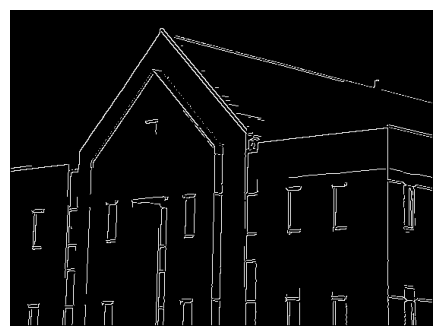

In [ ]:
def my_canny(img, low_thresh=90, high_thresh=150, sigma=2, kernel_size=3):
    blurred = cv2.GaussianBlur(img, (kernel_size, kernel_size), sigma)

    Gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    Gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

    magnitude = np.sqrt(Gx**2 + Gy**2)
    angle = np.arctan2(Gy, Gx) * (180 / np.pi)

    angle_quant = np.zeros_like(angle)
    angle_quant[(angle >= -22.5) & (angle < 22.5)] = 0
    angle_quant[(angle >= 22.5) & (angle < 67.5)] = 45
    angle_quant[(angle >= 67.5) & (angle < 112.5)] = 90
    angle_quant[(angle >= 112.5) | (angle < -112.5)] = 135
    angle_quant[(angle >= -112.5) & (angle < -67.5)] = 135
    angle_quant[(angle >= -67.5) & (angle < -22.5)] = 45

    suppressed = np.zeros_like(magnitude)
    h, w = magnitude.shape

    for i in range(1, h-1):
        for j in range(1, w-1):
            direction = angle_quant[i, j]
            val = magnitude[i, j]

            if direction == 0:
                if val >= magnitude[i, j-1] and val >= magnitude[i, j+1]:
                    suppressed[i, j] = val
            elif direction == 90:
                if val >= magnitude[i-1, j] and val >= magnitude[i+1, j]:
                    suppressed[i, j] = val
            elif direction == 45:
                if val >= magnitude[i-1, j+1] and val >= magnitude[i+1, j-1]:
                    suppressed[i, j] = val
            elif direction == 135:
                if val >= magnitude[i-1, j-1] and val >= magnitude[i+1, j+1]:
                    suppressed[i, j] = val

    strong = (suppressed >= high_thresh)
    weak = (suppressed >= low_thresh) & (suppressed < high_thresh)

    result = np.zeros_like(img, dtype=np.uint8)
    stack = [(i,j) for i in range(h) for j in range(w) if strong[i,j]]
    visited = np.zeros_like(img, dtype=bool)

    while stack:
        y, x = stack.pop()
        if visited[y, x]: continue
        visited[y, x] = True
        result[y, x] = 255

        for dy in [-1,0,1]:
            for dx in [-1,0,1]:
                ny, nx = y+dy, x+dx
                if 0 <= ny < h and 0 <= nx < w and weak[ny,nx] and not visited[ny,nx]:
                    stack.append((ny,nx))

    return result

edges_my = my_canny(img)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(edges_my, cmap='gray')
plt.axis('off')
plt.show()

## Algorytm Canny'ego - OpenCV

1. Wykonaj dektekcję krawędzi metodą Canny'ego wykorzystując funkcję `cv2.Canny`.
    - Pierwszym argumentem funkcji jest obraz wejściowy.
    - Drugim argumentem jest mniejszy próg.
    - Trzecim argumentem jest większy próg.
    - Czwarty argument to tablica, do której wpisany zostanie wynik.
    Można zwrócić go przez wartość i podać wartość `None`.
    - Piąty argument to rozmiar operatora Sobela (w naszym przypadku 3).
    - Szósty argument to rodzaj używanej normy.
    0 oznacza normę $L_1$, 1 oznacza normę $L_2$. Użyj $L_2$.
2. Wynik wyświetl i porównaj z własną implementacją.

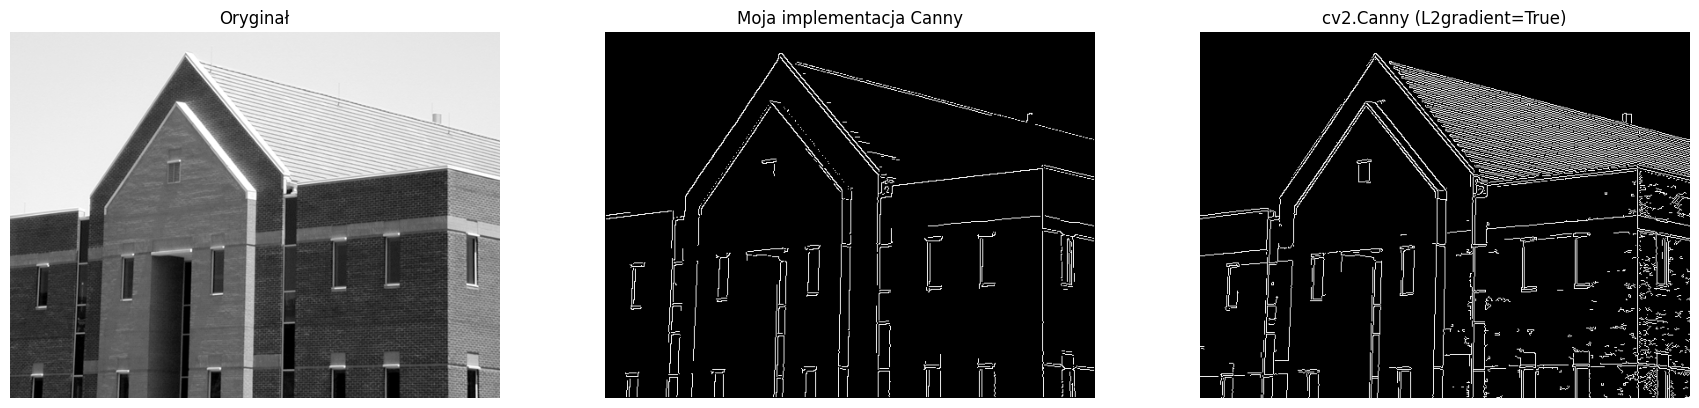

In [ ]:
edges_cv2 = cv2.Canny(img, threshold1=90, threshold2=150, apertureSize=3, L2gradient=True)
plt.figure(figsize=(18,8))
plt.subplot(2,3,1); plt.title("Oryginał"); plt.imshow(img, cmap='gray'); plt.axis('off')
plt.subplot(2,3,2); plt.title("Moja implementacja Canny"); plt.imshow(edges_my, cmap='gray'); plt.axis('off')
plt.subplot(2,3,3); plt.title("cv2.Canny (L2gradient=True)"); plt.imshow(edges_cv2, cmap='gray'); plt.axis('off')
plt.axis(False)
plt.tight_layout()
plt.show()